In [1]:
import subprocess, sys

def run(cmd):
    subprocess.run(cmd, shell=True, check=False)

print("Installing packages...")
run("pip install ultralytics -q")
run("pip install torch torchvision "
    "--index-url https://download.pytorch.org/whl/cu121 -q")
run("pip install scikit-learn matplotlib seaborn -q")
print("Done.\n")

Installing packages...
Done.



In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
from PIL import Image
import torchvision.transforms as T

print("=" * 60)
print("GC-CAR  —  YOLO11m Garbage Classifier Training")
print("=" * 60)
print(f"Python     : {sys.version.split()[0]}")
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.version.cuda}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU        : {props.name}")
    print(f"VRAM       : {props.total_memory / 1e9:.1f} GB")
else:
    print("GPU        : NOT AVAILABLE (training will be slow)")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("=" * 60)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GC-CAR  —  YOLO11m Garbage Classifier Training
Python     : 3.12.13
PyTorch    : 2.10.0+cu128
CUDA       : 12.8
GPU        : Tesla T4
VRAM       : 15.6 GB


In [4]:
# Path to your uploaded 'prepared_dataset' folder on Google Drive
DRIVE_DATASET_PATH = "/content/drive/MyDrive/prepared_dataset"   # <── CHANGE

COLAB_DATASET_PATH = "/content/gc_car_dataset"     # Temp fast local copy
DRIVE_OUTPUT_DIR   = "/content/drive/MyDrive/gc_car_trained_model"
PROJECT_DIR        = "/content/runs/classify"
RUN_NAME           = "gc_car_yolo11m"

# ── Training hyperparameters (tuned for Colab T4 / 15 GB VRAM) ─
CFG = dict(
    model          = "yolo11m-cls.pt",  # YOLO11m classification
    epochs         = 100,
    imgsz          = 224,               # Standard for classification
    batch          = 64,
    workers        = 4,
    lr0            = 0.001,
    lrf            = 0.01,
    momentum       = 0.9,
    weight_decay   = 0.0005,
    warmup_epochs  = 3,
    optimizer      = "AdamW",
    patience       = 25,                # Early stopping
    amp            = True,              # Mixed precision FP16
    augment        = True,
    label_smoothing= 0.1,
    dropout        = 0.0,
    pretrained     = True,
    seed           = 42,
    deterministic  = True,
    save_period    = 10,
    plots          = True,
    verbose        = True,
)

In [5]:
print("\n[STEP 1] Copying dataset from Google Drive to Colab /content/drive/MyDrive/prepared_dataset")
print("(Training directly from Drive is 3–5× slower)")

if os.path.exists(COLAB_DATASET_PATH):
    shutil.rmtree(COLAB_DATASET_PATH)

shutil.copytree(DRIVE_DATASET_PATH, COLAB_DATASET_PATH)
print("Copy done.\n")

# Verify
print("Dataset contents:")
for split in ["train", "val", "test"]:
    for cls in ["hazardous", "non_hazardous"]:
        p = Path(COLAB_DATASET_PATH) / split / cls
        if p.exists():
            n = len(list(p.glob("*.jpg")))
            bar = "█" * (n // 200)
            print(f"  {split:5s}/{cls:15s}: {n:6d}  {bar}")


[STEP 1] Copying dataset from Google Drive to Colab /content/drive/MyDrive/prepared_dataset
(Training directly from Drive is 3–5× slower)
Copy done.

Dataset contents:
  train/hazardous      :   3659  ██████████████████
  train/non_hazardous  :   6148  ██████████████████████████████
  val  /hazardous      :    457  ██
  val  /non_hazardous  :    768  ███
  test /hazardous      :    458  ██
  test /non_hazardous  :    774  ███


In [6]:
print(f"\n[STEP 2] Loading YOLO11m-cls (pretrained on ImageNet)...")
model = YOLO(CFG["model"])
total_params = sum(p.numel() for p in model.model.parameters())
print(f"Parameters : {total_params:,}")

print(f"\n[STEP 3] Starting training  ({CFG['epochs']} epochs max)")
print("=" * 60)
t0 = time.time()

results = model.train(
    data           = COLAB_DATASET_PATH,
    epochs         = CFG["epochs"],
    imgsz          = CFG["imgsz"],
    batch          = CFG["batch"],
    device         = DEVICE,
    workers        = CFG["workers"],
    lr0            = CFG["lr0"],
    lrf            = CFG["lrf"],
    momentum       = CFG["momentum"],
    weight_decay   = CFG["weight_decay"],
    warmup_epochs  = CFG["warmup_epochs"],
    optimizer      = CFG["optimizer"],
    patience       = CFG["patience"],
    amp            = CFG["amp"],
    augment        = CFG["augment"],
    label_smoothing= CFG["label_smoothing"],
    dropout        = CFG["dropout"],
    pretrained     = CFG["pretrained"],
    seed           = CFG["seed"],
    deterministic  = CFG["deterministic"],
    save_period    = CFG["save_period"],
    plots          = CFG["plots"],
    verbose        = CFG["verbose"],
    project        = PROJECT_DIR,
    name           = RUN_NAME,
    exist_ok       = True,
    val            = True,
    save           = True,
)

elapsed = time.time() - t0
print(f"\nTraining complete in {elapsed/60:.1f} minutes")


[STEP 2] Loading YOLO11m-cls (pretrained on ImageNet)...
Parameters : 11,634,216

[STEP 3] Starting training  (100 epochs max)
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gc_car_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=3

In [9]:
WEIGHTS_DIR = f"{PROJECT_DIR}/{RUN_NAME}/weights"
best_pt     = f"{WEIGHTS_DIR}/best.pt"

print("\n[STEP 4] Validating best model on test split...")
best_model  = YOLO(best_pt)
val_result  = best_model.val(
    data   = COLAB_DATASET_PATH,
    imgsz  = CFG["imgsz"],
    batch  = 32,
    device = DEVICE,
    split  = "test",
    augment= False,
    plots  = True,
)
print(f"\nTop-1 Accuracy : {val_result.top1 * 100:.2f}%")
print(f"Top-5 Accuracy : {val_result.top5 * 100:.2f}%")


[STEP 4] Validating best model on test split...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-cls summary (fused): 57 layers, 10,344,194 parameters, 0 gradients, 39.3 GFLOPs
train: /content/gc_car_dataset/train... found 9807 images in 2 classes ✅ 
val: /content/gc_car_dataset/val... found 1225 images in 2 classes ✅ 
test: /content/gc_car_dataset/test... found 1232 images in 2 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1785.1±935.9 MB/s, size: 78.4 KB)
test: Scanning /content/gc_car_dataset/test... 1232 images, 0 corrupt: 100% ━━━━━━━━━━━━ 1232/1232 323.0Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 39/39 2.8it/s 13.8s
                   all      0.957          1
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val-2

Top-1 Accuracy : 95.70%
Top-5 Accuracy : 100.00%



[STEP 5] Computing detailed classification metrics...
Classes: ['hazardous', 'non_hazardous']
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs


Classification Report:
               precision    recall  f1-score   support

    hazardous     0.9412    0.9432    0.9422       458
non_hazardous     0.9664    0.9651    0.9657       774

     accuracy                         0.9570      1232
    macro avg     0.9538    0.9542    0.9540      1232
 weighted avg     0.9570    0.9570    0.9570      1232

Confusi

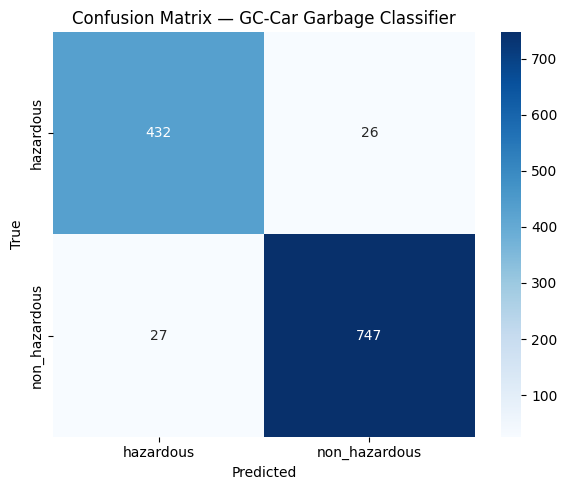

In [10]:
print("\n[STEP 5] Computing detailed classification metrics...")

test_dir    = Path(COLAB_DATASET_PATH) / "test"
class_names = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
cls_to_idx  = {c: i for i, c in enumerate(class_names)}
print(f"Classes: {class_names}")

test_items = []
for cls_name in class_names:
    img_paths = sorted((test_dir / cls_name).glob("*.*"))
    for img_path in img_paths:
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
            test_items.append((img_path, cls_to_idx[cls_name]))

if not test_items:
    raise RuntimeError(f"No test images found in: {test_dir}")

test_paths = [str(p) for p, _ in test_items]
all_labels = np.array([label for _, label in test_items], dtype=int)
all_preds  = []
all_probs  = []

results = best_model.predict(
    source=test_paths,
    imgsz=CFG["imgsz"],
    batch=32,
    device=DEVICE,
    verbose=False,
)

for res in results:
    probs = res.probs
    if probs is None:
        raise RuntimeError("Prediction returned no class probabilities.")
    all_preds.append(int(probs.top1))
    all_probs.append(probs.data.cpu().numpy())

all_preds = np.array(all_preds, dtype=int)
all_probs = np.vstack(all_probs)

if len(all_preds) != len(all_labels):
    raise RuntimeError(
        f"Prediction count mismatch: got {len(all_preds)} predictions for {len(all_labels)} test images."
    )

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    labels=list(range(len(class_names))),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(class_names))))
print(f"Confusion Matrix:\n{cm}")

if len(class_names) == 2:
    pos_idx = class_names.index("hazardous") if "hazardous" in class_names else 1
    auc = roc_auc_score((all_labels == pos_idx).astype(int), all_probs[:, pos_idx])
    print(f"ROC-AUC Score : {auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=class_names, yticklabels=class_names)
ax.set_title("Confusion Matrix — GC-Car Garbage Classifier")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/{RUN_NAME}/confusion_matrix_detailed.png", dpi=150)
plt.show()


In [11]:
print(f"\n[STEP 6] Saving to Google Drive: {DRIVE_OUTPUT_DIR}")
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

shutil.copy(best_pt, f"{DRIVE_OUTPUT_DIR}/gc_car_yolo11m_best.pt")
shutil.copy(f"{WEIGHTS_DIR}/last.pt", f"{DRIVE_OUTPUT_DIR}/gc_car_yolo11m_last.pt")

for fname in ["results.png", "confusion_matrix.png",
              "confusion_matrix_detailed.png"]:
    src = Path(f"{PROJECT_DIR}/{RUN_NAME}/{fname}")
    if src.exists():
        shutil.copy(src, f"{DRIVE_OUTPUT_DIR}/{fname}")

print(f"\nModel saved to Google Drive successfully!")
print(f"\n{'='*60}")
print("TRAINING COMPLETE!")
print(f"{'='*60}")
print("Next steps:")
print(f"  1. Download  gc_car_yolo11m_best.pt  from Drive")
print(f"  2. Place it in  GC_Car_Project/05_model/")
print(f"  3. Run  06_inference/esp32_live_inference.py  on laptop")
print(f"{'='*60}")


[STEP 6] Saving to Google Drive: /content/drive/MyDrive/gc_car_trained_model

Model saved to Google Drive successfully!

TRAINING COMPLETE!
Next steps:
  1. Download  gc_car_yolo11m_best.pt  from Drive
  2. Place it in  GC_Car_Project/05_model/
  3. Run  06_inference/esp32_live_inference.py  on laptop
